# Part I - Bike ride Dataset Exploration
## by Anindya Chaudhuri

## Introduction

The data consists of information regarding 183,000 rides made in a bike sharing system covering the greater San Francisco Bay area. 

Key features include:  
- duration (secs) 
- start, end time
- start, end station id name, location
- bike id 
- user type
- birth year
- gender 


> Introduce the dataset

>**Rubric Tip**: Your code should not generate any errors, and should use functions, loops where possible to reduce repetitive code. Prefer to use functions to reuse code statements.

> **Rubric Tip**: Document your approach and findings in markdown cells. Use comments and docstrings in code cells to document the code functionality.

>**Rubric Tip**: Markup cells should have headers and text that organize your thoughts, findings, and what you plan on investigating next.  

## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.

> Note that the collective size of all your files in the current worksapce **must not exceed 1 GB** in total. 


In [2]:
df = pd.read_csv('201902-fordgobike-tripdata.csv')
print("Shape of bike sharing data ---> ", df.shape)

Shape of bike sharing data --->  (183412, 16)


In [3]:
# Check few sample data - first 4 rows

print("First four rows from the dataset.")
df.head(4)

First four rows from the dataset.


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No


## Basic information on bike ride data

In [4]:
print("Basic information of the dataset - like datatype etc.")
df.info()

Basic information of the dataset - like datatype etc.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  membe

In [5]:
print("A quick statistical summary of the  DataFrame.")
df.describe()

A quick statistical summary of the  DataFrame.


,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [6]:
print("Check the number of missing values for each column.")
df.isnull().sum()

Check the number of missing values for each column.


duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [7]:
def remove_missing_rows(df, col_name):
    print(f"Removing rows where {col_name} is missing.")
    return df[df[col_name].notnull()]

# Remove rows that does not have gender value
print("Rows with missing values in `member_gender` are removed, since gender is needed for the analysis and records without it are not useful for this part of the study.")
df_clean = remove_missing_rows(df, 'member_gender')
df_clean.info()


Rows with missing values in `member_gender` are removed, since gender is needed for the analysis and records without it are not useful for this part of the study.
Removing rows where member_gender is missing.
<class 'pandas.core.frame.DataFrame'>
Index: 175147 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             175147 non-null  int64  
 1   start_time               175147 non-null  object 
 2   end_time                 175147 non-null  object 
 3   start_station_id         174952 non-null  float64
 4   start_station_name       174952 non-null  object 
 5   start_station_latitude   175147 non-null  float64
 6   start_station_longitude  175147 non-null  float64
 7   end_station_id           174952 non-null  float64
 8   end_station_name         174952 non-null  object 
 9   end_station_latitude     175147 non-null  float64
 10  end_station_longitud

In [8]:
def df_value_counts(df, col_name):
    return df[col_name].value_counts()

print("Check count of each gender category.")
df_value_counts(df_clean, 'member_gender')    

Check count of each gender category.


member_gender
Male      130651
Female     40844
Other       3652
Name: count, dtype: int64

In [9]:
print("Check count of each user_type category.")
df_value_counts(df_clean, 'user_type')

Check count of each user_type category.


user_type
Subscriber    158516
Customer       16631
Name: count, dtype: int64

In [10]:
print("Removing rows with missing start_station_id because station-based analysis requires valid station information.")
df_clean = remove_missing_rows(df_clean,'start_station_id')
df_clean.info()

Removing rows with missing start_station_id because station-based analysis requires valid station information.
Removing rows where start_station_id is missing.
<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             174952 non-null  int64  
 1   start_time               174952 non-null  object 
 2   end_time                 174952 non-null  object 
 3   start_station_id         174952 non-null  float64
 4   start_station_name       174952 non-null  object 
 5   start_station_latitude   174952 non-null  float64
 6   start_station_longitude  174952 non-null  float64
 7   end_station_id           174952 non-null  float64
 8   end_station_name         174952 non-null  object 
 9   end_station_latitude     174952 non-null  float64
 10  end_station_longitude    174952 non-null  float64
 11  bike_id       

In [11]:
print("Check for duplicates now... ")
df_clean.duplicated().sum()

Check for duplicates now... 


0

In [12]:
print("Convert `start_time` and `end_time` to datetime format for consistent date-time analysis.")
df_clean = df_clean.copy()
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'])

Convert `start_time` and `end_time` to datetime format for consistent date-time analysis.


In [13]:
# Extract dayofweek, hours information from the start_time

print("Extracting day of week and hour from start_time.")
df_clean['start_time_dayofweek']= df_clean['start_time'].dt.strftime('%a')
df_clean['start_time_hour']= df_clean['start_time'].dt.hour

Extracting day of week and hour from start_time.


In [14]:
print("Basic information of the cleaned dataset.")
df_clean.info()

Basic information of the cleaned dataset.
<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174952 non-null  int64         
 1   start_time               174952 non-null  datetime64[ns]
 2   end_time                 174952 non-null  datetime64[ns]
 3   start_station_id         174952 non-null  float64       
 4   start_station_name       174952 non-null  object        
 5   start_station_latitude   174952 non-null  float64       
 6   start_station_longitude  174952 non-null  float64       
 7   end_station_id           174952 non-null  float64       
 8   end_station_name         174952 non-null  object        
 9   end_station_latitude     174952 non-null  float64       
 10  end_station_longitude    174952 non-null  float64       
 11  bike_id                  174952 non-null 

In [15]:
## Final set of sample data - first four rows
print("First four rows from the cleaned dataset.")
df_clean.head(4)

First four rows from the cleaned dataset.


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_time_dayofweek,start_time_hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,Thu,17
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,Thu,12
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,Thu,17
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,Thu,23


In [16]:
print("Retrieving the count of records for each day of the week.")
df_value_counts(df_clean, 'start_time_dayofweek')

Retrieving the count of records for each day of the week.


start_time_dayofweek
Thu    33712
Tue    30584
Wed    28426
Fri    27663
Mon    25641
Sun    14512
Sat    14414
Name: count, dtype: int64

In [17]:
# Convert the start_time_dayofweek to meaningful names.

print("Converting start_time_dayofweek to an ordered categorical variable.")
weekdays = ['Mon','Tue','Wed','Thu','Fri', 'Sat', 'Sun']
ordered_weekdays = pd.api.types.CategoricalDtype(ordered = True, categories = weekdays)
df_clean['start_time_dayofweek'] = df_clean['start_time_dayofweek'].astype(ordered_weekdays)

Converting start_time_dayofweek to an ordered categorical variable.


In [18]:
print("Check the cleaned data again.")
df_clean.info()

Check the cleaned data again.
<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174952 non-null  int64         
 1   start_time               174952 non-null  datetime64[ns]
 2   end_time                 174952 non-null  datetime64[ns]
 3   start_station_id         174952 non-null  float64       
 4   start_station_name       174952 non-null  object        
 5   start_station_latitude   174952 non-null  float64       
 6   start_station_longitude  174952 non-null  float64       
 7   end_station_id           174952 non-null  float64       
 8   end_station_name         174952 non-null  object        
 9   end_station_latitude     174952 non-null  float64       
 10  end_station_longitude    174952 non-null  float64       
 11  bike_id                  174952 non-null  int64      

In [19]:
# Calculate member_age from member_birth_year till 2019 as the file is prepared till this year.

print("Calculating age of the member from the birth year.")
df_clean['member_age'] = 2019 - df_clean['member_birth_year']

df_clean['member_age'] = df_clean['member_age'].astype(int)
df_clean['member_birth_year'] = df_clean['member_birth_year'].astype(int)

Calculating age of the member from the birth year.


In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174952 non-null  int64         
 1   start_time               174952 non-null  datetime64[ns]
 2   end_time                 174952 non-null  datetime64[ns]
 3   start_station_id         174952 non-null  float64       
 4   start_station_name       174952 non-null  object        
 5   start_station_latitude   174952 non-null  float64       
 6   start_station_longitude  174952 non-null  float64       
 7   end_station_id           174952 non-null  float64       
 8   end_station_name         174952 non-null  object        
 9   end_station_latitude     174952 non-null  float64       
 10  end_station_longitude    174952 non-null  float64       
 11  bike_id                  174952 non-null  int64         
 12  user_type            

In [21]:
df_clean.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_time_dayofweek,start_time_hour,member_age
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984,Male,No,Thu,17,35
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972,Male,No,Thu,12,47
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989,Other,No,Thu,17,30
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974,Male,Yes,Thu,23,45
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959,Male,No,Thu,23,60


In [22]:
print("Checking the shape of the cleaned data now.")
df_clean.shape

Checking the shape of the cleaned data now.


(174952, 19)

In [23]:
print("The data is cleaned and transformed into a more consistent format, making it ready for exploratory analysis and visualization.")

The data is cleaned and transformed into a more consistent format, making it ready for exploratory analysis and visualization.


In [24]:
print("Checking unique values for user_type, member_gender and bike_share_for_all_trip.")
print(df_clean['user_type'].unique())
print(df_clean['member_gender'].unique())
print(df_clean['bike_share_for_all_trip'].unique())

Checking unique values for user_type, member_gender and bike_share_for_all_trip.
['Customer' 'Subscriber']
['Male' 'Other' 'Female']
['No' 'Yes']


### What is the structure of your dataset?

> There are 174,952 bike ride records in the cleaned dataset with 19 variables. These include dutation of trip, trip start and end times, station information, bike ID, user type, member birth year, gender, bike-share usage, and derived features such as start day of week, start hour, and member age.


### What is/are the main feature(s) of interest in your dataset?

> Main feature of interest: The main feature of interest is trip duration.


### What features in the dataset do you think will help support your investigation into your feature(s) of interest?
  
> Supporting features: Supporting features include   
    member age, 
    member gender, 
    user type, 
    start day of week, 
    start hour, and 
    bike-share status.

## Univariate Exploration

> In this section, investigate distributions of individual variables. If you see unusual points or outliers, take a deeper look to clean things up and prepare yourself to look at relationships between variables.

>**Rubric Tip**: Use the "Question-Visualization-Observations" framework  throughout the exploration. This framework involves **asking a question from the data, creating a visualization to find answers, and then recording observations after each visualisation.** 

> **Rubric Tip**: This part (Univariate Exploration) should include at least one histogram, and either a bar chart of count plot.

>**Rubric Tip**: Visualizations should depict the data appropriately so that the plots are easily interpretable. You should choose an appropriate plot type, data encodings, and formatting as needed. The formatting may include setting/adding the title, labels, legend, and comments. Also, do not overplot or incorrectly plot ordinal data.

## 1 - We will look at the attribute duration.

## We will convert duration from seconds to minutes for easier investigation.

In [25]:
df_clean['duration_min'] = df_clean['duration_sec']/60
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174952 non-null  int64         
 1   start_time               174952 non-null  datetime64[ns]
 2   end_time                 174952 non-null  datetime64[ns]
 3   start_station_id         174952 non-null  float64       
 4   start_station_name       174952 non-null  object        
 5   start_station_latitude   174952 non-null  float64       
 6   start_station_longitude  174952 non-null  float64       
 7   end_station_id           174952 non-null  float64       
 8   end_station_name         174952 non-null  object        
 9   end_station_latitude     174952 non-null  float64       
 10  end_station_longitude    174952 non-null  float64       
 11  bike_id                  174952 non-null  int64         
 12  user_type            

In [26]:
df_clean.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_time_dayofweek,start_time_hour,member_age,duration_min
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984,Male,No,Thu,17,35,869.750000
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972,Male,No,Thu,12,47,1030.900000
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989,Other,No,Thu,17,30,608.166667
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974,Male,Yes,Thu,23,45,26.416667
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959,Male,No,Thu,23,60,29.883333


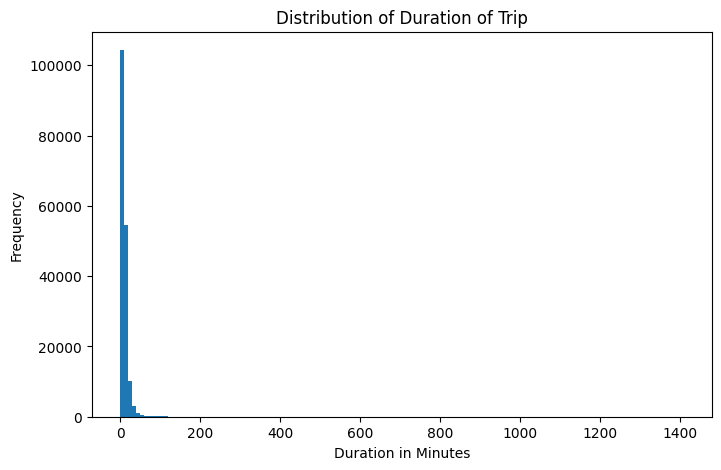

In [27]:
binsize = 10
bins = np.arange(0, df_clean['duration_min'].max()+binsize, binsize)

plt.figure(figsize=[8, 5])
plt.title('Distribution of Duration of Trip')
plt.xlabel('Duration in Minutes')
plt.ylabel('Frequency')
plt.hist(data = df_clean, x = 'duration_min', bins=bins)
plt.show()

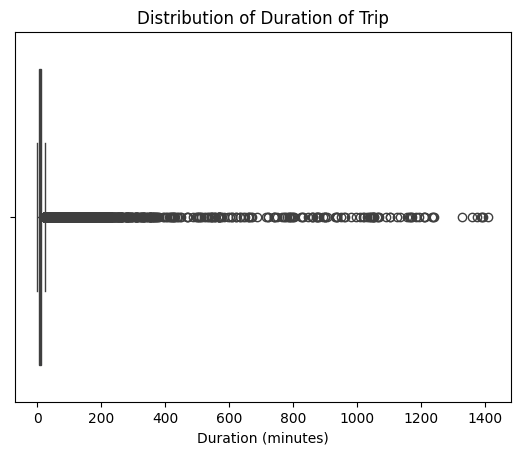

In [28]:
ax = sns.boxplot(data=df_clean, x='duration_min')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('')
ax.set_title('Distribution of Duration of Trip')
plt.show()

## It appears most data are below 30. Let look into the distribution.

In [29]:
print("Let us check the details of duration_min")
df_clean['duration_min'].describe()

Let us check the details of duration_min


count    174952.000000
mean         11.733379
std          27.370082
min           1.016667
25%           5.383333
50%           8.500000
75%          13.150000
max        1409.133333
Name: duration_min, dtype: float64

## The data is not distributed normally. Let us check the IQR:

IQR = Q3 - Q1 = 13.150000 - 5.383333 = 7.766667
Upper Whisker Bound = (1.5 * IQR) + Q3 = 25.1500005

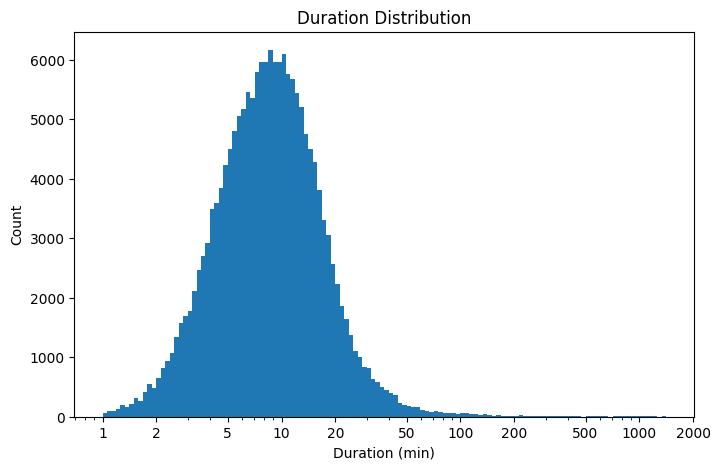

In [30]:
## There's a long tail in the distribution. Let us transform in log scale. 
log_binsize = 0.025
bins = 10 ** np.arange(0, np.log10(df_clean['duration_min'].max())+log_binsize, log_binsize)

plt.figure(figsize=[8, 5]);
plt.hist(data = df_clean, x = 'duration_min', bins = bins);
plt.xscale('log');
plt.xticks([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000], [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]);
plt.xlabel('Duration (min)')
plt.ylabel('Count')
plt.title('Duration Distribution')
plt.show()

## log transform made the distribution less skewed and easier to inspect. 

## Still there is a long tail after duration 100 minutes. These are not wrong records. In order to focus the analysis we should limit duration till 100 minutes.

In [31]:
# Consider the records records with duration_min < 100 min
df_clean = df_clean[df_clean['duration_min'] <= 100].copy().reset_index(drop=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174249 entries, 0 to 174248
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174249 non-null  int64         
 1   start_time               174249 non-null  datetime64[ns]
 2   end_time                 174249 non-null  datetime64[ns]
 3   start_station_id         174249 non-null  float64       
 4   start_station_name       174249 non-null  object        
 5   start_station_latitude   174249 non-null  float64       
 6   start_station_longitude  174249 non-null  float64       
 7   end_station_id           174249 non-null  float64       
 8   end_station_name         174249 non-null  object        
 9   end_station_latitude     174249 non-null  float64       
 10  end_station_longitude    174249 non-null  float64       
 11  bike_id                  174249 non-null  int64         
 12  user_type       

## Note - 1 - Duration attribute

## Question: What is the distribution of the attribute duration?
## Visualization: histogram / log histogram / boxplot
## Observation:  The majority of trips are short, with a strongly right-skewed distribution and long tail. Trips above 100 minutes were excluded to focus the analysis on the main mass of the distribution. Also the duration distribution was heavily right-skewed and these long trips represented a very small share of observations. 

## 2 - Now we will look at member age.

In [32]:
df_clean['member_age'].describe()

count    174249.000000
mean         34.191972
std          10.117930
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max         141.000000
Name: member_age, dtype: float64

## We can see the max age is appearing as 141 and it is not normal.

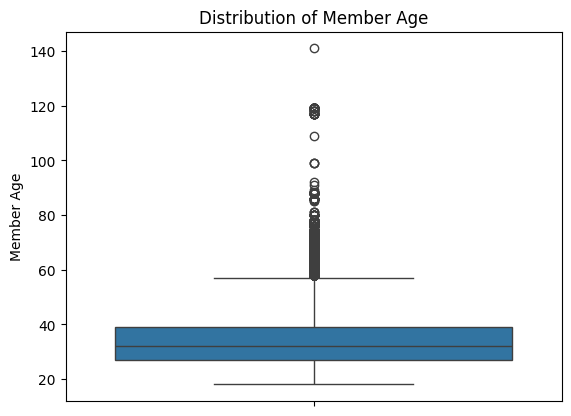

In [33]:
ax = sns.boxplot(data=df_clean, y='member_age')
plt.title('Distribution of Member Age')
plt.ylabel('Member Age')
plt.xlabel('')
plt.show()

## The data is not distributed evenly. Let us calculate the IQR:

IQR = Q3 - Q1 = 39.0 - 27.0 = 12.0
Upper Whisker Bound = (1.5 * IQR) + Q3 = 18.0 + 39.0 = 57.0

In [34]:
## It is evident that some ages are implausibly high.
## The distribution contains extreme outliers.
## Filtering these values helps focus the analysis on plausible rider ages, without 
## claiming that ages above 60 are impossible or invalid.
## Let's remove outliers and keep records with member_age below 60.

df_clean = df_clean[df_clean['member_age'] <= 60].copy().reset_index(drop=True)

In [35]:
df_clean.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_time_dayofweek,start_time_hour,member_age,duration_min
0,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974,Male,Yes,Thu,23,45,26.416667
1,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959,Male,No,Thu,23,60,29.883333
2,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983,Female,No,Thu,23,36,19.116667
3,1615,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989,Male,No,Thu,23,30,26.916667
4,1570,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988,Other,No,Thu,23,31,26.166667


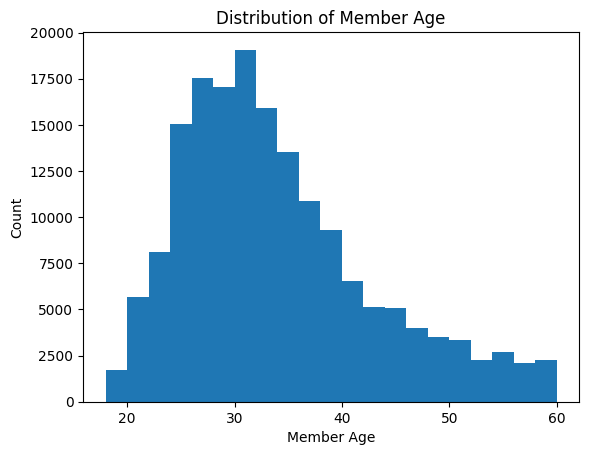

In [36]:
binsize = 2
bins = np.arange(18, df_clean['member_age'].max() + binsize, binsize)

plt.hist(data=df_clean, x='member_age', bins=bins)
plt.title('Distribution of Member Age')
plt.xlabel('Member Age')
plt.ylabel('Count')
plt.show()

## The distribution looks better now. 

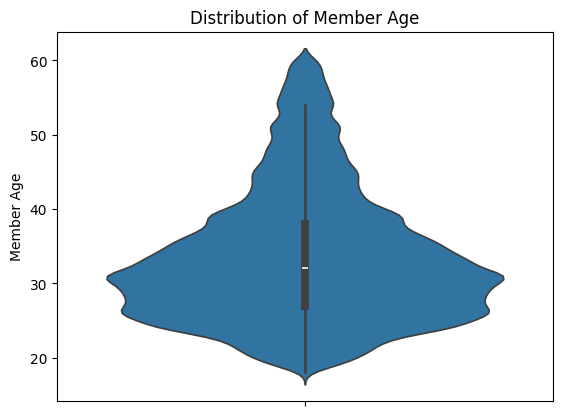

In [37]:
sns.violinplot(data=df_clean, y='member_age')
plt.title('Distribution of Member Age')
plt.ylabel('Member Age')
plt.xlabel('')
plt.show()

## The distribution is not even. Many cyclists are around 30 years old and not many cyclists are over 40 years.

## Note - 2 - member_age attribute

## Question: What is the distribution of the attribute member_age?
## Visualization: histogram / boxplot
## Observation: The member_age data had outliers. We calculated IQR and Upper Whisker Bound and it appears ages above 60 are at an extreme end for this analysis. Hence, we have removed records with age greater than 60. Most riders are between 20 and 40 years old after filtering implausible age outliers. 

## 3 - Now we will look into start_time_hour and start_time_dayofweek attributes. 

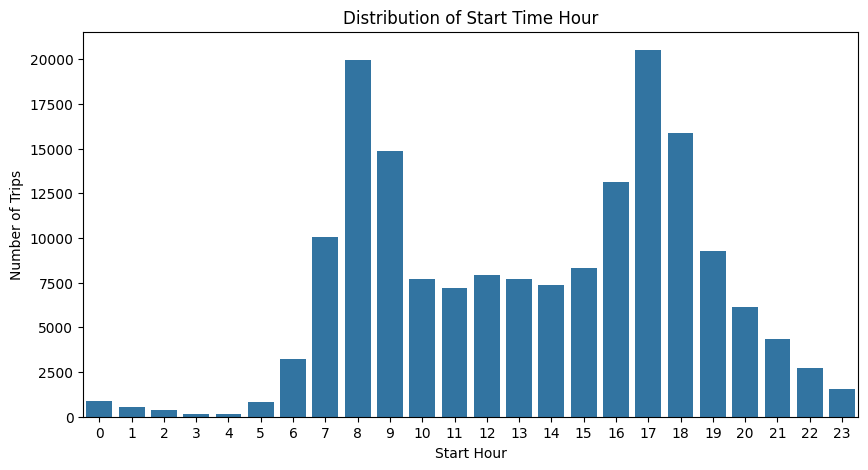

In [38]:
default_color = sns.color_palette()[0]
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='start_time_hour', color=default_color)
plt.title('Distribution of Start Time Hour')
plt.xlabel('Start Hour')
plt.ylabel('Number of Trips')
plt.show()

## It is evident 7:00 - 9:00 am and 4:00 - 6:00 pm are the two peak hours ranges.

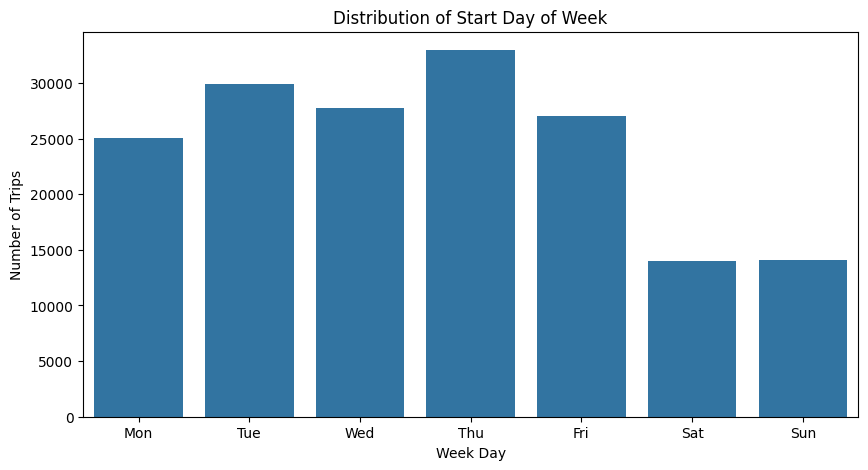

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='start_time_dayofweek', color=default_color)
plt.title('Distribution of Start Day of Week')
plt.xlabel('Week Day')
plt.ylabel('Number of Trips')
plt.show()

## Weekday trips are highest on Tuesday and Thursday, while weekends have lower counts.


## Note - 3 - start_time_hour and start_time_dayofweek attributes

## Question: What are the distributions?
## Visualization: countplot
## Observation: It is evident that - Tuesday had the highest trip count in this dataset and the trip counts peak during commute hours, especially around 7–9 AM and 4–6 PM.

## 4 - Now we will look into member_gender attribute. 

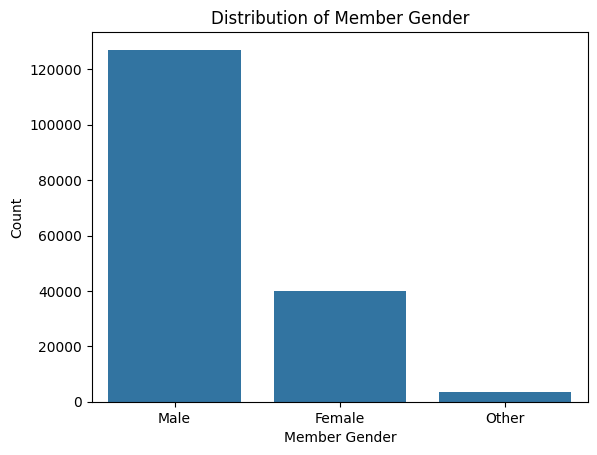

In [40]:
sns.countplot(data=df_clean, x='member_gender', color=default_color)
plt.title('Distribution of Member Gender')
plt.xlabel('Member Gender')
plt.ylabel('Count')
plt.show()

## Note - 4 - member_gender attribute

## Question: What is the distribution?
## Visualization: countplot
## Observation: The majority of riders are male, while the 'Other' category contains relatively few observations.


## 5 - Now we will look into user_type attribute. 

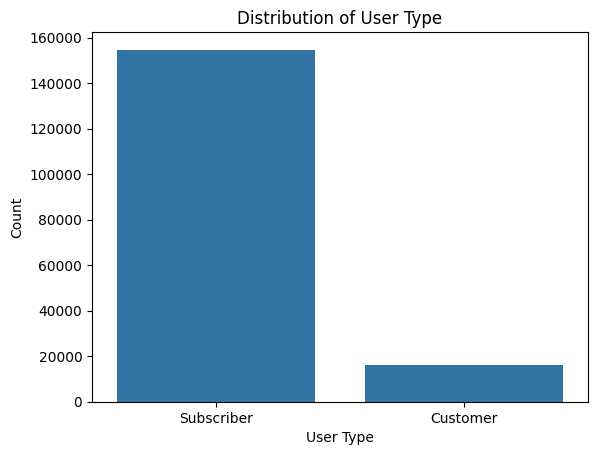

In [41]:
sns.countplot(data=df_clean, x='user_type', color=default_color)
plt.title('Distribution of User Type')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.show()

## Note - 5 - user_type attribute

## Question: What is the distribution?
## Visualization: countplot
## Observation: The majority of riders are Subscribers.

In [42]:
## 6 - Now we will check bike_share_for_all_trip attribute.

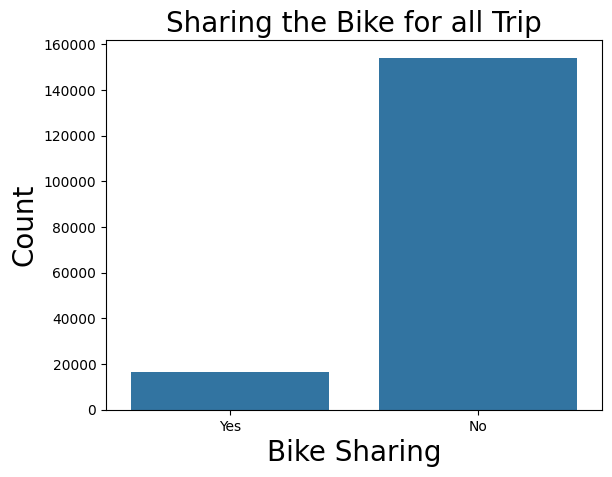

In [43]:
sns.countplot(data=df_clean,x='bike_share_for_all_trip',color=default_color)
plt.xlabel('Bike Sharing',size=20)
plt.ylabel('Count',size=20)
plt.title('Sharing the Bike for all Trip',size=20)
plt.show()

## Note - 6 - bike_share_for_all_trip attribute

## Question: What is the distribution?
## Visualization: countplot
## Observation: Most users didn't share the bike for all trip. 

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> Regarding the Duration - Majority of the trips are short. The distribution had a strong right skew and long tail. Trips above 100 minutes were excluded from the focused analysis because the duration distribution was heavily right-skewed and these long trips represented a very small share of observations.


### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> For member_age - The member_age data had outliers. We calculated IQR and Upper Whisker Bound and it appears ages above 60 are at an extreme end for this analysis. Hence, we have removed records with age greater than 60. Most riders are between 20 and 40 years old after filtering implausible age outliers.

> For start_time_dayofweek and start_time_hour - It is evident that - Weekday trips are highest on Tuesday and Thursday, while weekends. Also the trip counts peak during commute hours, especially around 7–9 AM and 4–6 PM.

> For member_gender - The majority of riders are male, while the 'Other' category contains relatively few observations.

> For and user_type - The majority of riders are Subscribers.

> For and bike_share_for_all_trip - Most users didn't share the bike for all trip.

## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).

> **Rubric Tip**: This part (Bivariate Exploration) should include at least one scatter plot, one box plot, and at least one clustered bar chart or heat map.

## 1. Let us check duration_min and member_age attributes

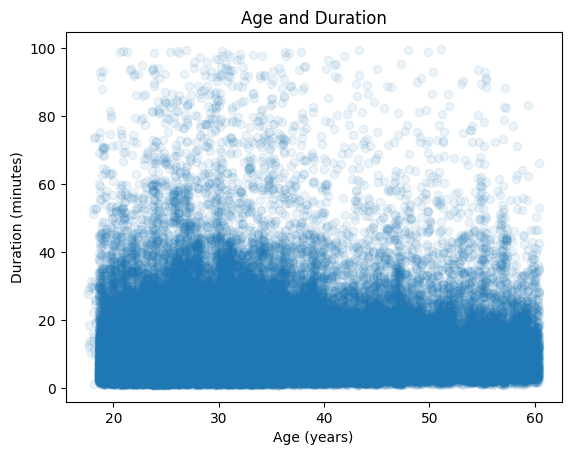

In [44]:
sns.regplot(data=df_clean,x='member_age',y='duration_min',fit_reg=False, x_jitter=0.4, scatter_kws={'alpha':1/12})
plt.xlabel('Age (years)')
plt.ylabel('Duration (minutes)')
plt.title('Age and Duration')
plt.show()

## Note - 1 - Duration and member age

## Question: What is the distribution?
## Visualization: Regression plot
## Observation: The scatter plot shows a weak negative relationship between age and duration of trip.

## 2. Let us check duration_min and user_type attributes

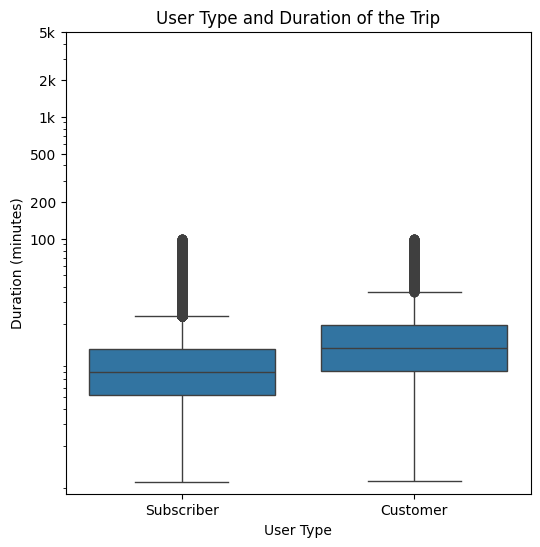

In [45]:
plt.figure(figsize=[6,6])
sns.boxplot(data=df_clean,x='user_type',y='duration_min',color=default_color)
plt.yscale('log')
y_ticklocs=[100,200,500,1e3,2e3,5e3]
y_ticklabels=['100','200','500','1k','2k','5k']
plt.yticks(y_ticklocs,y_ticklabels)
plt.xlabel('User Type')
plt.ylabel('Duration (minutes)')
plt.title('User Type and Duration of the Trip')
plt.show()

## Note - 2 - Duration and user_type

## Question: What is the distribution?
## Visualization: boxplot
## Observation: Customers have longer trips than subscribers. 

## 3. Let us check duration_min and member_gender attributes

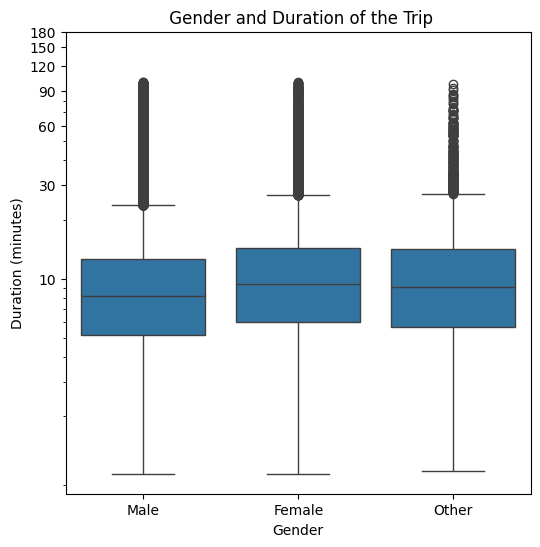

In [46]:
plt.figure(figsize=[6,6])
sns.boxplot(data=df_clean,x='member_gender',y='duration_min',color=default_color,order=['Male','Female','Other'])
plt.yscale('log')
y_ticklocs=[10, 30, 60, 90, 120, 150, 180]
y_ticklabels=['10', '30', '60', '90', '120', '150', '180']
plt.yticks(y_ticklocs,y_ticklabels)
plt.xlabel('Gender')
plt.ylabel('Duration (minutes)')
plt.title(' Gender and Duration of the Trip')
plt.show()

## Note - 3 - Duration and gender

## Question: What is the distribution?
## Visualization: boxplot
## Observation: Male riders appear to have slightly shorter duration of trips than the other genders, though the difference is not large.

## 4. Let us check duration_min and bike_share_for_all_trip attributes

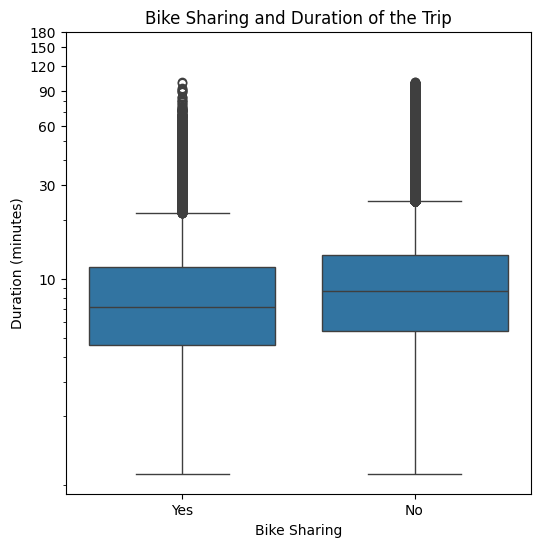

In [47]:
plt.figure(figsize=[6,6])
sns.boxplot(data=df_clean,x='bike_share_for_all_trip',y='duration_min',color=default_color)
plt.yscale('log')
y_ticklocs=[10, 30, 60, 90, 120, 150, 180]
y_ticklabels=['10', '30', '60', '90', '120', '150', '180']
plt.yticks(y_ticklocs,y_ticklabels)
plt.xlabel('Bike Sharing')
plt.ylabel('Duration (minutes)')
plt.title('Bike Sharing and Duration of the Trip')
plt.show()

## Note - 4 - Duration and bikesharing

## Question: What is the distribution?
## Visualization: boxplot
## Observation: Non-bike-share trips tend to have longer durations. 

## 5. Let us check relationship of age and bike sharing.

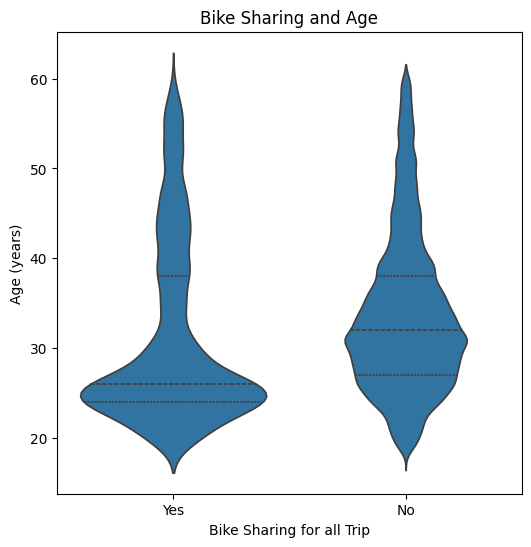

In [48]:
plt.figure(figsize=[6,6])
sns.violinplot(data=df_clean,x='bike_share_for_all_trip',y='member_age',color=default_color,inner='quartile')
plt.xlabel('Bike Sharing for all Trip')
plt.ylabel ('Age (years)');
plt.title('Bike Sharing and Age')
plt.show()

## Note - 5 - Age and bike sharing

## Question: What is the distribution?
## Visualization: violinplot
## Observation: Bike-share users appear somewhat younger on average.

## 6. Let us check relationship of user type and age.

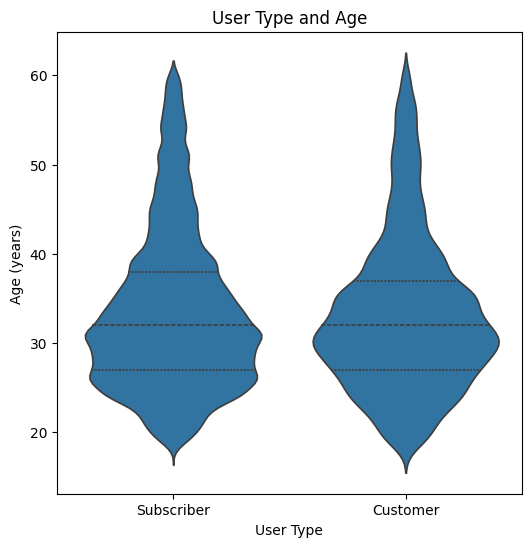

In [49]:
plt.figure(figsize=[6,6])
sns.violinplot(data=df_clean,x='user_type',y='member_age',color=default_color,inner='quartile')
plt.xlabel('User Type')
plt.ylabel ('Age (years)')
plt.title('User Type and Age')
plt.show()

## Note - 6 - User type and age

## Question: What is the distribution?
## Visualization: violinplot
## Observation: There does not appear to be a large age difference between user types.

## 7. Let us check relationship of gender and bike sharing.

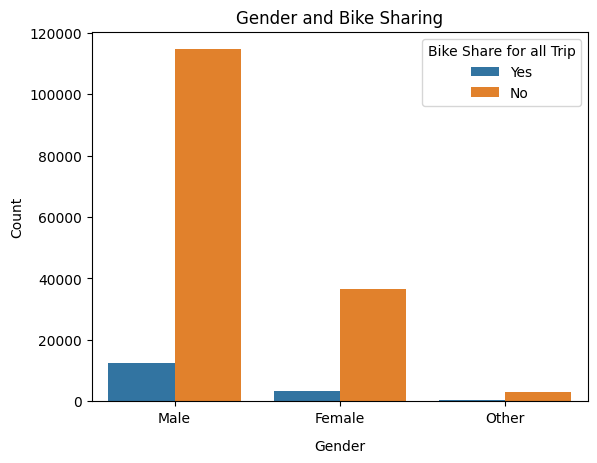

In [50]:
sns.countplot(data=df_clean,x='member_gender',hue='bike_share_for_all_trip')
plt.xlabel('Gender',labelpad=10)
plt.ylabel('Count')
plt.legend(title='Bike Share for all Trip')
plt.title('Gender and Bike Sharing')
plt.show()

## Note - 7 - gender and Bike sharing

## Question: What is the distribution?
## Visualization: clustered bar chart / countplot
## Observation: In raw counts, male riders appear more frequently across both user types than females and other genders.  

## 8. Let us check relationship of gender and user type

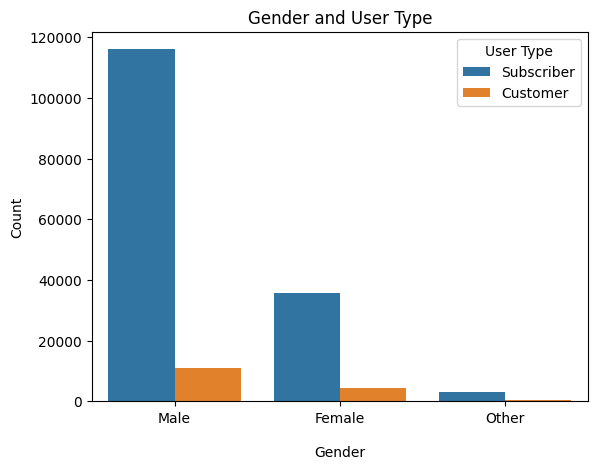

In [51]:
sns.countplot(data=df_clean,x='member_gender',hue='user_type')
plt.xlabel('Gender',labelpad=15)
plt.ylabel('Count')
plt.legend(title='User Type')
plt.title('Gender and User Type')
plt.show()

## Note - 8 - gender and user type

## Question: What is the distribution?
## Visualization: clustered bar chart / countplot
## Observation: In raw counts, male riders appear more frequently across both user types than females and other genders.

## 9. Let us check relationship of user type and bike sharing

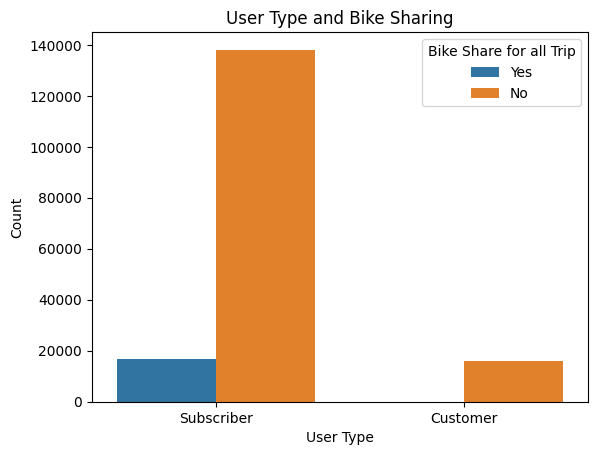

In [52]:
sns.countplot(data=df_clean,x='user_type',hue='bike_share_for_all_trip')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.legend(title='Bike Share for all Trip')
plt.title('User Type and Bike Sharing')
plt.show()

## Note - 9 - user type and bike sharing

## Question: What is the distribution?
## Visualization: clustered bar chart / countplot
## Observation: Bike sharing occurs only among subscribers.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> The scatter plot shows a weak negative relationship between age and duration of trip.

> Customers have longer trips than subscribers.

> Male riders appear to have slightly shorter durations of trip than the other genders, though the difference is not large.


> Non-bike-share trips tend to have longer durations. 

> There is not much difference of user types across ages.

> There does not appear to be a large age difference between user types.


> In raw counts, male riders most frequently appear in the non-bike-share category, followed by females and other genders.

> In raw counts, male riders appear more frequently across both user types than females and other genders.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Bike-share users appear somewhat younger on average.

> Bike sharing occurs only among subscribers.

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

> **Rubric Tip**: This part (Multivariate Exploration) should include at least one Facet Plot, and one Plot Matrix or Scatterplot with multiple encodings.

>**Rubric Tip**: Think carefully about how you encode variables. Choose appropriate color schemes, markers, or even how Facets are chosen. Also, do not overplot or incorrectly plot ordinal data.

## 1. Let us check relationship between the Age and the Duration for all user types

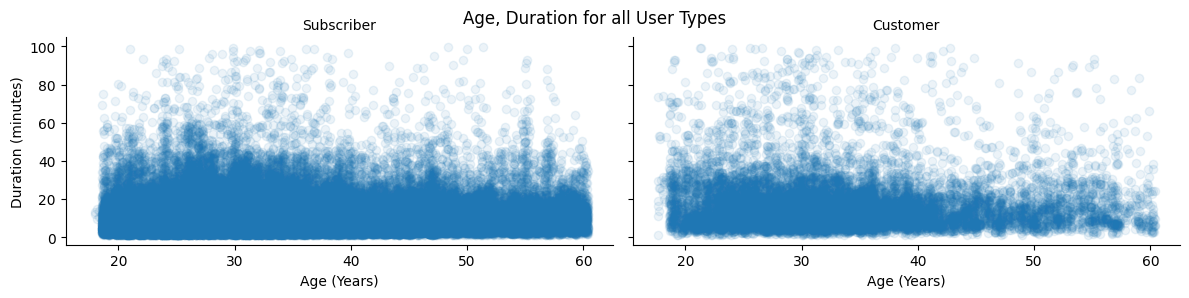

In [53]:
fgrid=sns.FacetGrid(data=df_clean,col='user_type',height=3,aspect=2)
fgrid.map_dataframe(sns.regplot,data=df_clean, x='member_age',y='duration_min',fit_reg=False, x_jitter=0.4, scatter_kws={'alpha':1/12})
fgrid.set_titles('{col_name}')
fgrid.set_axis_labels('Age (Years)','Duration (minutes)')
plt.suptitle('Age, Duration for all User Types')
plt.show()

## Note - 1 - Age and the Duration for all user types

## Question: What is the distribution?
## Visualization: FacetGrid / regplot
## Observation: The relationship between age and duration of trip appears broadly similar across user types. 

## 2 - Age and the Duration for all gender

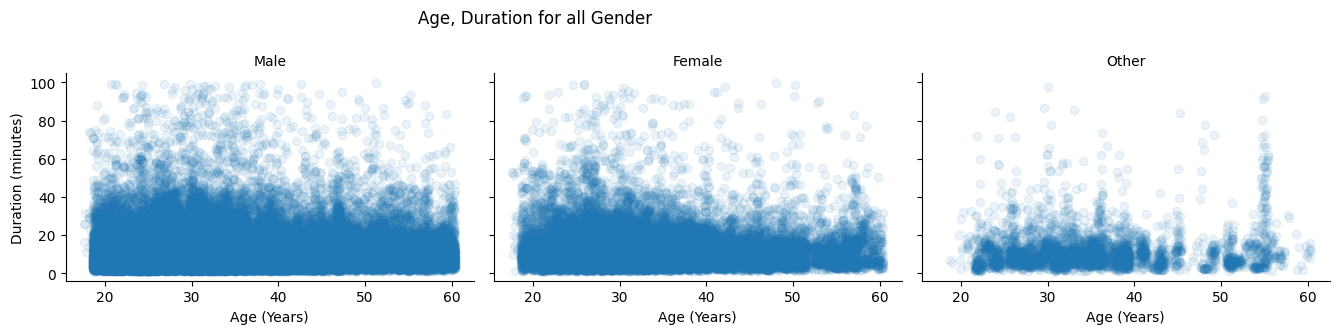

In [54]:
fgrid=sns.FacetGrid(data=df_clean,col='member_gender',height=3,aspect=1.5)
fgrid.map_dataframe(sns.regplot,data=df_clean, x='member_age',y='duration_min',fit_reg=False, x_jitter=0.4, scatter_kws={'alpha':1/12})
fgrid.set_titles('{col_name}')
fgrid.set_axis_labels('Age (Years)','Duration (minutes)')
plt.suptitle('Age, Duration for all Gender',x=0.4,y=1.1)
plt.show()

## Note - 2 - Age and the Duration for all gender

## Question: What is the distribution?
## Visualization: FacetGrid / regplot
## Observation: The relationship between age and duration of trip appears broadly similar across all genders.

## 3 - Age and the Duration for all bike sharing types

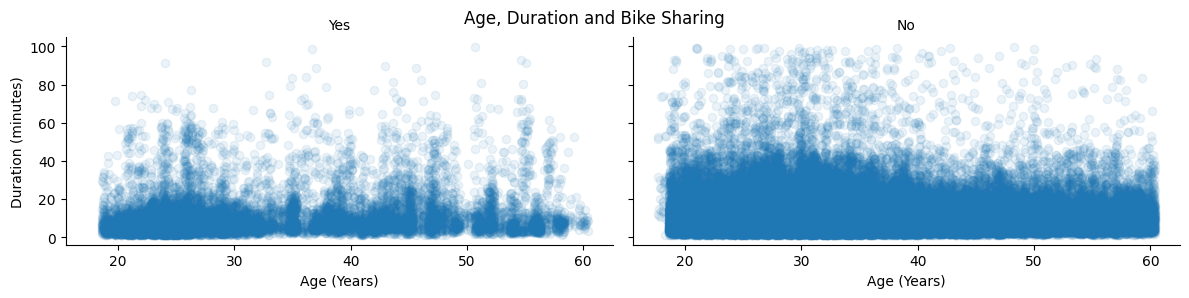

In [55]:
fgrid=sns.FacetGrid(data=df_clean,col='bike_share_for_all_trip',height=3,aspect=2)
fgrid.map_dataframe(sns.regplot,data=df_clean, x='member_age',y='duration_min',fit_reg=False, x_jitter=0.4, scatter_kws={'alpha':1/12})
fgrid.set_titles('{col_name}')
fgrid.set_axis_labels('Age (Years)','Duration (minutes)')
plt.suptitle('Age, Duration and Bike Sharing')
plt.show()

## Note - 3 - Age and the Duration for all bike sharing types

## Question: What is the distribution?
## Visualization: FacetGrid / regplot
## Observation: The relationship between age and duration of trip appears broadly similar across bike sharing categories.

## 4 - Duration by gender and bike sharing status

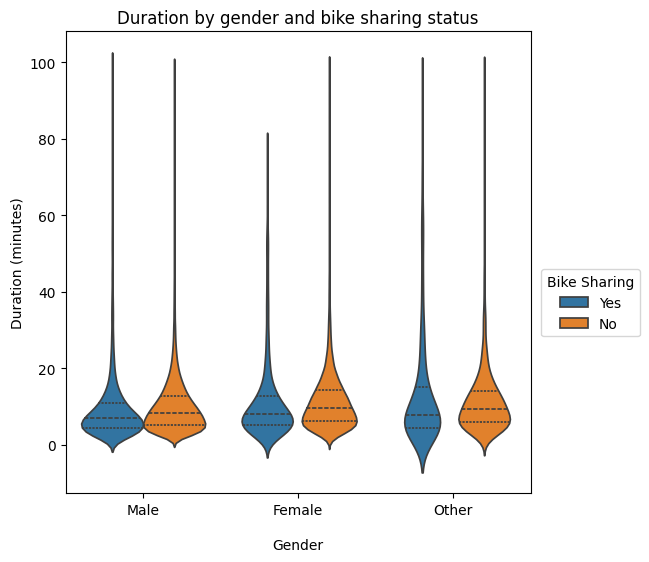

In [56]:
plt.figure(figsize=[6,6])
sns.violinplot(data=df_clean,x='member_gender',y='duration_min',hue='bike_share_for_all_trip',inner='quartile')
plt.xlabel('Gender', labelpad=15)
plt.ylabel('Duration (minutes)')
plt.title('Duration by gender and bike sharing status')
plt.legend(title='Bike Sharing', bbox_to_anchor=(1.25,0.5))
plt.show()

## Note - 4 - Duration by gender and bike sharing status

## Question: What is the distribution?
## Visualization: violin plot
## Observation: Across genders, non-bike-share trips appear to have longer durations than bike-share trips.

## 5 - Duration by gender and user type

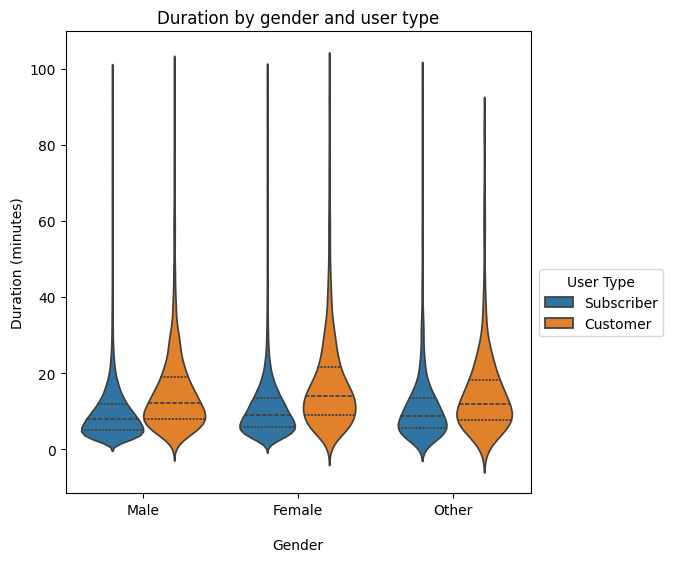

In [57]:
plt.figure(figsize=[6,6])
sns.violinplot(data=df_clean,x='member_gender',y='duration_min',hue='user_type',inner='quartile')
plt.xlabel('Gender', labelpad=15)
plt.ylabel('Duration (minutes)')
plt.title('Duration by gender and user type')
plt.legend(title='User Type', bbox_to_anchor=(1.3,0.5))
plt.show()

## Note - 5 - Duration by gender and user type

## Question: What is the distribution?
## Visualization: violin plot
## Observation: Subscribers have shorter trips than customers in all genders.

## 6 - Let us consider below scatter plot - Trip Duration vs Age by User Type and Gender

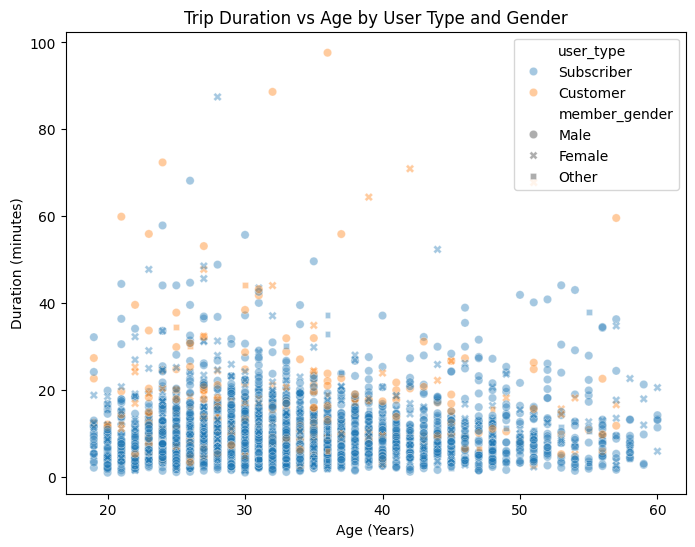

In [58]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clean.sample(3000, random_state=42),
    x='member_age',
    y='duration_min',
    hue='user_type',
    style='member_gender',
    alpha=0.4
)
plt.xlabel('Age (Years)')
plt.ylabel('Duration (minutes)')
plt.title('Trip Duration vs Age by User Type and Gender')
plt.show()

In [59]:
## Note - 6 - Trip Duration vs Age by User Type and Gender

## Question: What is the distribution?
## Visualization: scatterplot
## Observation: The scatterplot shows a wide spread of trip durations across rider ages, with no strong linear relationship.
## Most trips are concentrated at lower durations, while a few longer trips appear as scattered points.
## Because the data is sparse and overlapping, the chart is more useful for showing general spread than for identifying a clear pattern by age, user type, or gender.


### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?
> The negative relationship between age and duration of trip appears consistent across user types, genders, and bike sharing categories.

> Duration of trip differs more clearly by user type than by gender.

### Were there any interesting or surprising interactions between features?

> Subscribers tend to have shorter trips than customers across genders.

> Trip Duration vs Age by User Type and Gender - We generated a scatterplotand this  shows a wide spread of trip durations across rider ages, with no strong linear relationship. Most trips are concentrated at lower durations, while a few longer trips appear as scattered points. Because the data is sparse and overlapping, the chart is more useful for showing general spread than for identifying a clear pattern by age, user type, or gender.


In [60]:
# save cleaned data 
df_clean.to_csv('cleaned_bike_sharing_file.csv', index=False)

In [61]:
print('Stop here now... ')

Stop here now... 


## Conclusions
>The cleaned dataset contains 174,952 bike ride records and 19 variables. These variables include trip duration, trip start and end times, station information, bike ID, user type, member birth year, gender, bike-share usage, and derived features such as start day of week, start hour, and member age. The main feature of interest in this analysis is trip duration, while supporting features such as member age, member gender, user type, start day of week, start hour, and bike-share status help explain variation in trip behavior.

> In the univariate exploration, trip duration was found to be strongly right-skewed, with most trips being short and a small number of very long trips creating a long tail. To focus the analysis on the main distribution, trips longer than 100 minutes were excluded from the detailed exploration. Member age also contained extreme outliers, so records with ages above 60 were removed to focus the analysis on plausible rider ages. The remaining distributions showed that most riders were between 20 and 40 years old, most riders were male, most users were Subscribers, and most trips were not bike-share-for-all trips. Trip counts were also highest on weekdays, especially Tuesday and Thursday, and peaked during commute hours around 7–9 AM and 4–6 PM.

> In the bivariate exploration, trip duration showed a weak negative relationship with member age, suggesting that trip duration tends to decrease slightly as age increases. More noticeable differences appeared across user groups: Customers generally took longer trips than Subscribers, and non-bike-share trips also tended to have longer durations. Differences by gender were relatively small, although male riders appeared to have slightly shorter trip durations on average. Additional comparisons showed that bike-share users appeared somewhat younger on average, bike sharing occurred only among Subscribers, and male riders were the most common group across both user types and bike-share categories.

> In the multivariate exploration, the relationship between age and trip duration remained weak across user types, genders, and bike-share categories, indicating that age was not a strong predictor of trip duration even when considered alongside other variables. User type continued to show the clearest pattern, with Subscribers consistently taking shorter trips than Customers across genders. The scatterplot of trip duration versus age by user type and gender showed a wide and overlapping spread of points, with most trips concentrated at shorter durations and only a few long-duration trips scattered across ages. Overall, the multivariate analysis reinforced that user type had a stronger association with trip duration than either gender or age.

> **Rubric Tip**: Create a list of summary findings to make it easy to review.

> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML.


> At the end of your report, make sure that you export the notebook as an html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep track of where the exported file goes, so you can put it in the same folder as this notebook for project submission. Also, make sure you remove all of the quote-formatted guide notes like this one before you finish your report!

